In [1]:
!pip install huggingface_hub ipywidgets

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.0.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.11.8-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/texttable-1.7.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/igraph-0.11.8-py3.12-linux-aarch64.egg is deprecat

In [ ]:
from huggingface_hub import login, snapshot_download
import os
HUGGINGFACE_TOKEN = os.environ.get("HUGGINGFACE_TOKEN")
login(token=HUGGINGFACE_TOKEN, add_to_git_credential=True)
model_names = [
        # "Cosmos-0.1-Tokenizer-CI8x8",
        # "Cosmos-0.1-Tokenizer-CI16x16",
        "Cosmos-0.1-Tokenizer-DI8x8",
        "Cosmos-0.1-Tokenizer-DI16x16",
]
for model_name in model_names:
    hf_repo = "nvidia/" + model_name
    local_dir = "checkpoints/" + model_name
    os.makedirs(local_dir, exist_ok=True)
    print(f"downloading {model_name}...")
    snapshot_download(repo_id=hf_repo, local_dir=local_dir)

downloading Cosmos-0.1-Tokenizer-CI8x8...


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

downloading Cosmos-0.1-Tokenizer-CI16x16...


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

downloading Cosmos-0.1-Tokenizer-DI8x8...


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

downloading Cosmos-0.1-Tokenizer-DI16x16...


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

In [2]:
import cv2
import numpy as np
import torch

In [3]:
!pip install mediapy loguru einops

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.0.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.11.8-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/texttable-1.7.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/igraph-0.11.8-py3.12-linux-aarch64.egg is deprecat

In [4]:
!which python

/usr/bin/python


In [5]:
import importlib
from cosmos_predict1.tokenizer.inference.image_lib import ImageTokenizer
import mediapy as media

In [6]:
model_name = 'Cosmos-0.1-Tokenizer-DI8x8' # @param ["Cosmos-0.1-Tokenizer-CI16x16", "Cosmos-0.1-Tokenizer-CI8x8", "Cosmos-0.1-Tokenizer-DI8x8", "Cosmos-0.1-Tokenizer-DI16x16"]

encoder_ckpt = f"checkpoints/{model_name}/encoder.jit"
decoder_ckpt = f"checkpoints/{model_name}/decoder.jit"

Input image read from:	 /capstor/users/cscs/xyixuan/PDM/notebooks//capstor/users/cscs/xyixuan/cosmos-predict1/cosmos_predict1/tokenizer/test_data/draft.jpg
Reconstruction saved:	 /capstor/users/cscs/xyixuan/PDM/notebooks//capstor/users/cscs/xyixuan/cosmos-predict1/cosmos_predict1/tokenizer/test_data/draft_DI8x8.jpg


Input Image,Reconstructed Image

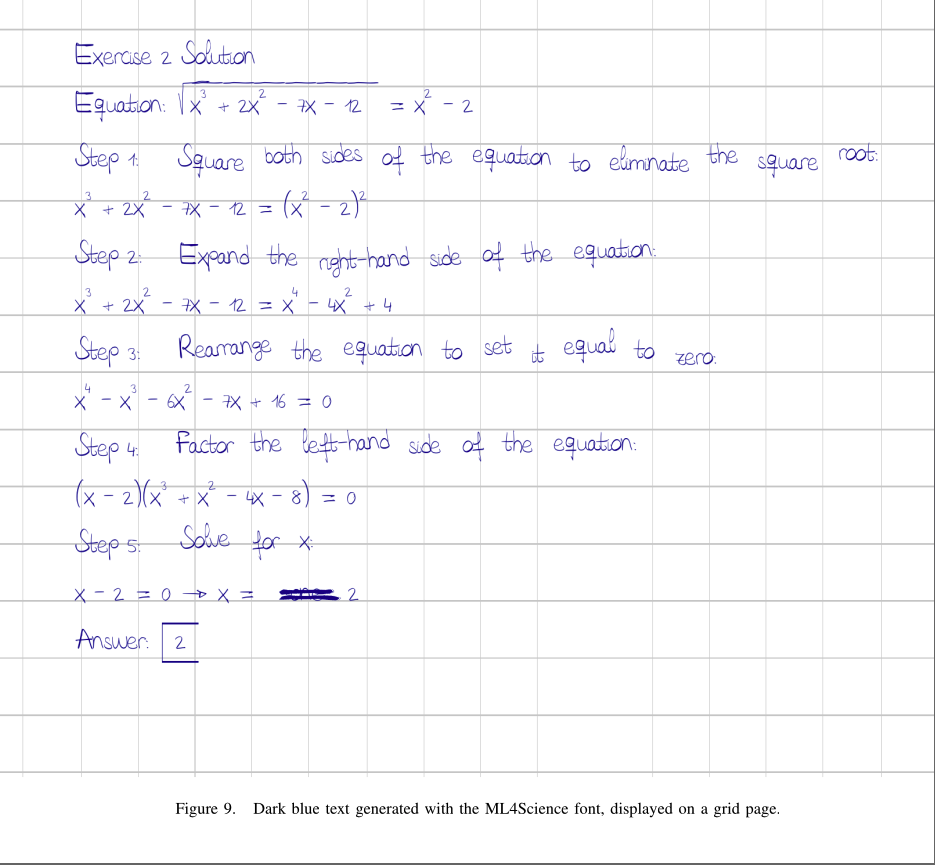
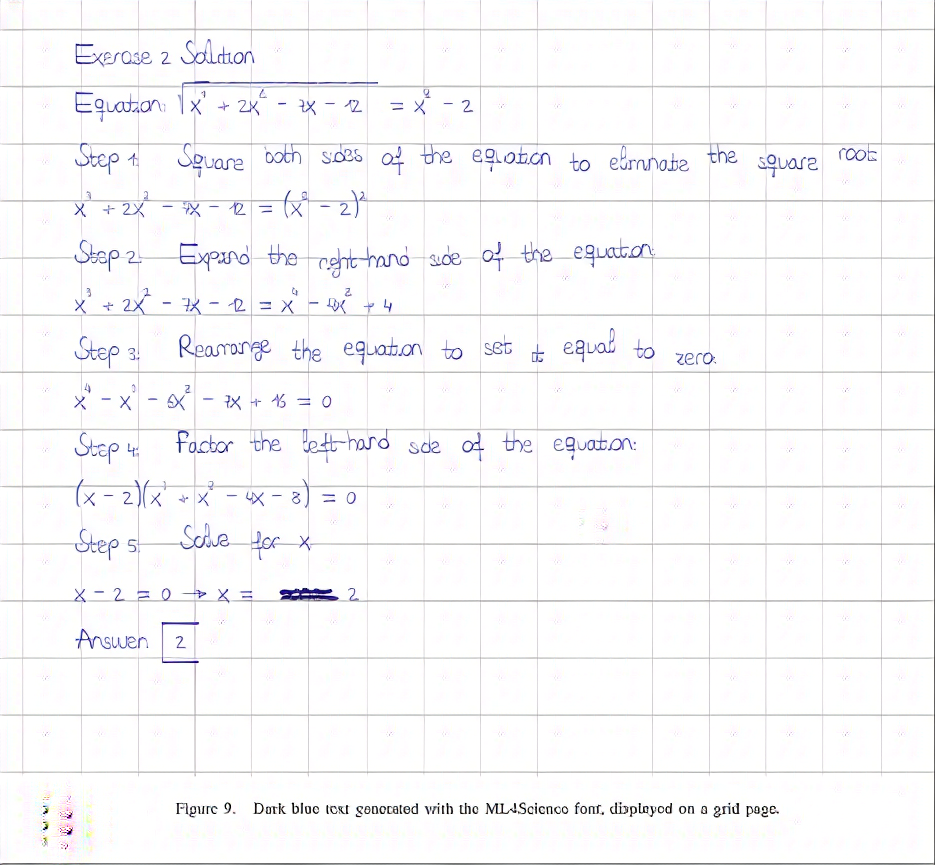

In [8]:
model_name = 'Cosmos-0.1-Tokenizer-DI8x8' # @param ["Cosmos-0.1-Tokenizer-CI16x16", "Cosmos-0.1-Tokenizer-CI8x8", "Cosmos-0.1-Tokenizer-DI8x8", "Cosmos-0.1-Tokenizer-DI16x16"]

encoder_ckpt = f"checkpoints/{model_name}/encoder.jit"
decoder_ckpt = f"checkpoints/{model_name}/decoder.jit"

# 3) Read the image from disk (shape = H x W x 3 in BGR). Then convert to RGB.
input_filepath = '/capstor/users/cscs/xyixuan/cosmos-predict1/cosmos_predict1/tokenizer/test_data/draft.jpg'
input_image = media.read_image(input_filepath)[..., :3]
assert input_image.ndim == 3 and input_image.shape[2] == 3, "Image must have shape H x W x 3"

# 4) Expand dimensions to B x H x W x C, since the ImageTokenizer expects a batch dimension
#    in the input. (Batch size = 1 in this example.)
batched_input_image = np.expand_dims(input_image, axis=0)

# 5) Create the ImageTokenizer instance with the encoder & decoder.
#    - device="cuda" uses the GPU
#    - dtype="bfloat16" expects Ampere or newer GPU (A100, RTX 30xx, etc.)
tokenizer = ImageTokenizer(
    checkpoint_enc=encoder_ckpt,
    checkpoint_dec=decoder_ckpt,
    device="cuda",
    dtype="bfloat16",
)

# 6) Use the tokenizer to autoencode (encode & decode) the image.
#    The output is a NumPy array with shape = B x H x W x C, range [0..255].
batched_output_image = tokenizer(batched_input_image)

# latents = tokenizer.encode(torch.tensor(batched_input_image).bfloat16().cuda())[0]
# print(latents)
# batched_output_image = tokenizer.decode(latents)

# 7) Extract the single image from the batch (index 0), convert to uint8.
output_image = batched_output_image[0]

# 9) Save the reconstructed image to disk.
input_dir, input_filename = os.path.split(input_filepath)
filename, ext = os.path.splitext(input_filename)
output_filepath = f"{input_dir}/{filename}_{model_name.split('-')[-1]}{ext}"
media.write_image(output_filepath, output_image)
print("Input image read from:\t", f"{os.getcwd()}/{input_filepath}")
print("Reconstruction saved:\t", f"{os.getcwd()}/{output_filepath}")

# 10) Visualization of the input image (left) and the reconstruction (right).
media.show_images([input_image, output_image], ["Input Image", "Reconstructed Image"])

In [11]:
from cosmos_predict1.tokenizer.inference.utils import (
    load_decoder_model,
    load_encoder_model,
    load_model,
    numpy2tensor,
    pad_image_batch,
    tensor2numpy,
    unpad_image_batch,
)

In [12]:
padded_input_image, crop_region = pad_image_batch(batched_input_image)
input_tensor = numpy2tensor(padded_input_image, dtype=getattr(torch, 'bfloat16'), device='cuda')

In [13]:
padded_input_image.shape

(1, 3472, 3744, 3)

In [14]:
crop_region

[6, 2, 3466, 3742]

In [46]:
input_tensor.shape

torch.Size([1, 3, 880, 944])

In [47]:
latents = tokenizer.encode(input_tensor)[0]


In [50]:
latents.shape

torch.Size([1, 110, 118])

In [22]:
output_tensor = tokenizer.decode(latents)

In [23]:
padded_output_image = tensor2numpy(output_tensor)

In [26]:
batched_output_image = unpad_image_batch(padded_output_image, crop_region)

Input image read from:	 /capstor/users/cscs/xyixuan/PDM/notebooks//capstor/users/cscs/xyixuan/cosmos-predict1/cosmos_predict1/tokenizer/test_data/WechatIMG254.jpg
Reconstruction saved:	 /capstor/users/cscs/xyixuan/PDM/notebooks//capstor/users/cscs/xyixuan/cosmos-predict1/cosmos_predict1/tokenizer/test_data/WechatIMG254_CI8x8.jpg


Input Image,Reconstructed Image

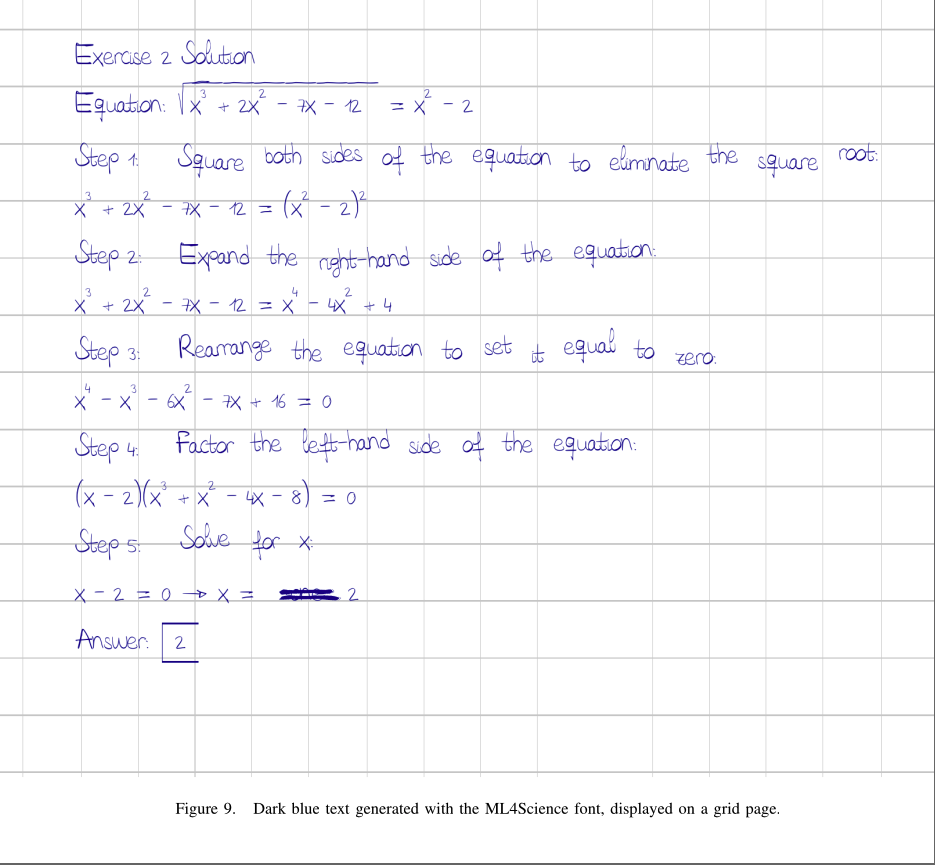
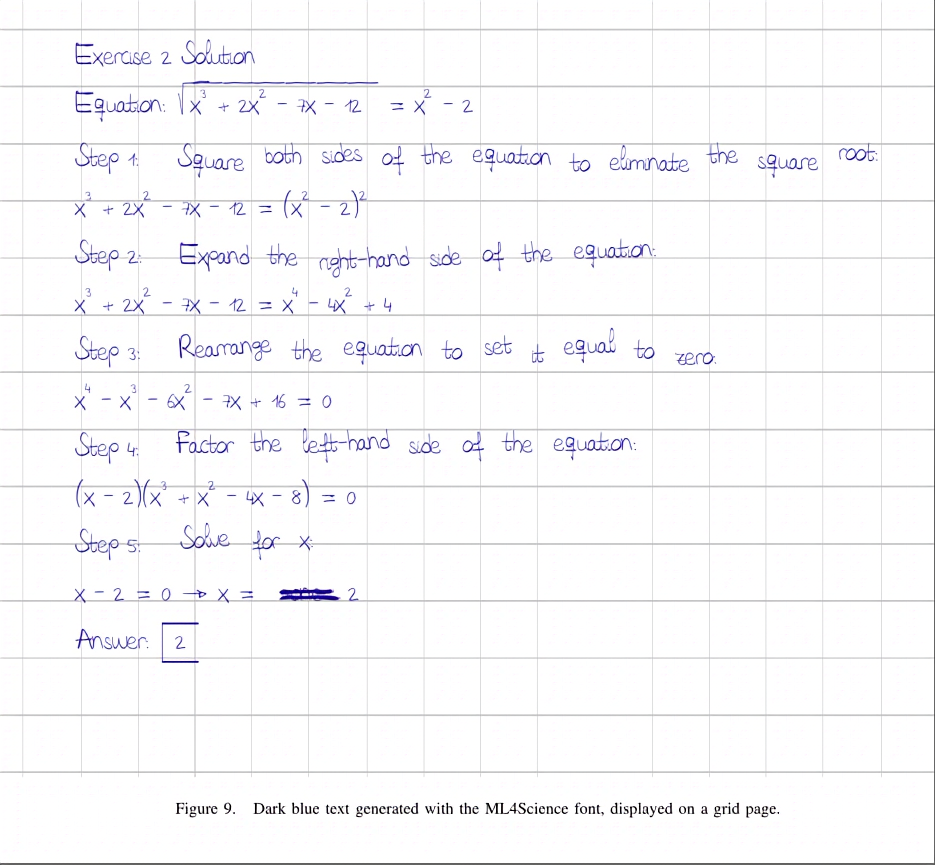

In [27]:
# 7) Extract the single image from the batch (index 0), convert to uint8.
output_image = batched_output_image[0]

# 9) Save the reconstructed image to disk.
input_dir, input_filename = os.path.split(input_filepath)
filename, ext = os.path.splitext(input_filename)
output_filepath = f"{input_dir}/{filename}_{model_name.split('-')[-1]}{ext}"
media.write_image(output_filepath, output_image)
print("Input image read from:\t", f"{os.getcwd()}/{input_filepath}")
print("Reconstruction saved:\t", f"{os.getcwd()}/{output_filepath}")

# 10) Visualization of the input image (left) and the reconstruction (right).
media.show_images([input_image, output_image], ["Input Image", "Reconstructed Image"])

In [1]:
import torch

In [5]:
print(torch.__version__)  # Check version

2.6.0+cpu


In [ ]:
print(torch.cuda.is_available()) 

False


Processing with Cosmos-0.1-Tokenizer-CI8x8...
  Saved high-quality image to: /capstor/users/cscs/xyixuan/cosmos-predict1/cosmos_predict1/tokenizer/test_data/draft_CI8x8_hq.jpg
Processing with Cosmos-0.1-Tokenizer-CI16x16...
  Saved high-quality image to: /capstor/users/cscs/xyixuan/cosmos-predict1/cosmos_predict1/tokenizer/test_data/draft_CI16x16_hq.jpg
Processing with Cosmos-0.1-Tokenizer-DI8x8...
  Saved high-quality image to: /capstor/users/cscs/xyixuan/cosmos-predict1/cosmos_predict1/tokenizer/test_data/draft_DI8x8_hq.jpg
Processing with Cosmos-0.1-Tokenizer-DI16x16...
  Saved high-quality image to: /capstor/users/cscs/xyixuan/cosmos-predict1/cosmos_predict1/tokenizer/test_data/draft_DI16x16_hq.jpg
High-quality PDF comparison saved to: /capstor/users/cscs/xyixuan/cosmos-predict1/cosmos_predict1/tokenizer/test_data/draft_cosmos_comparison_hq.pdf


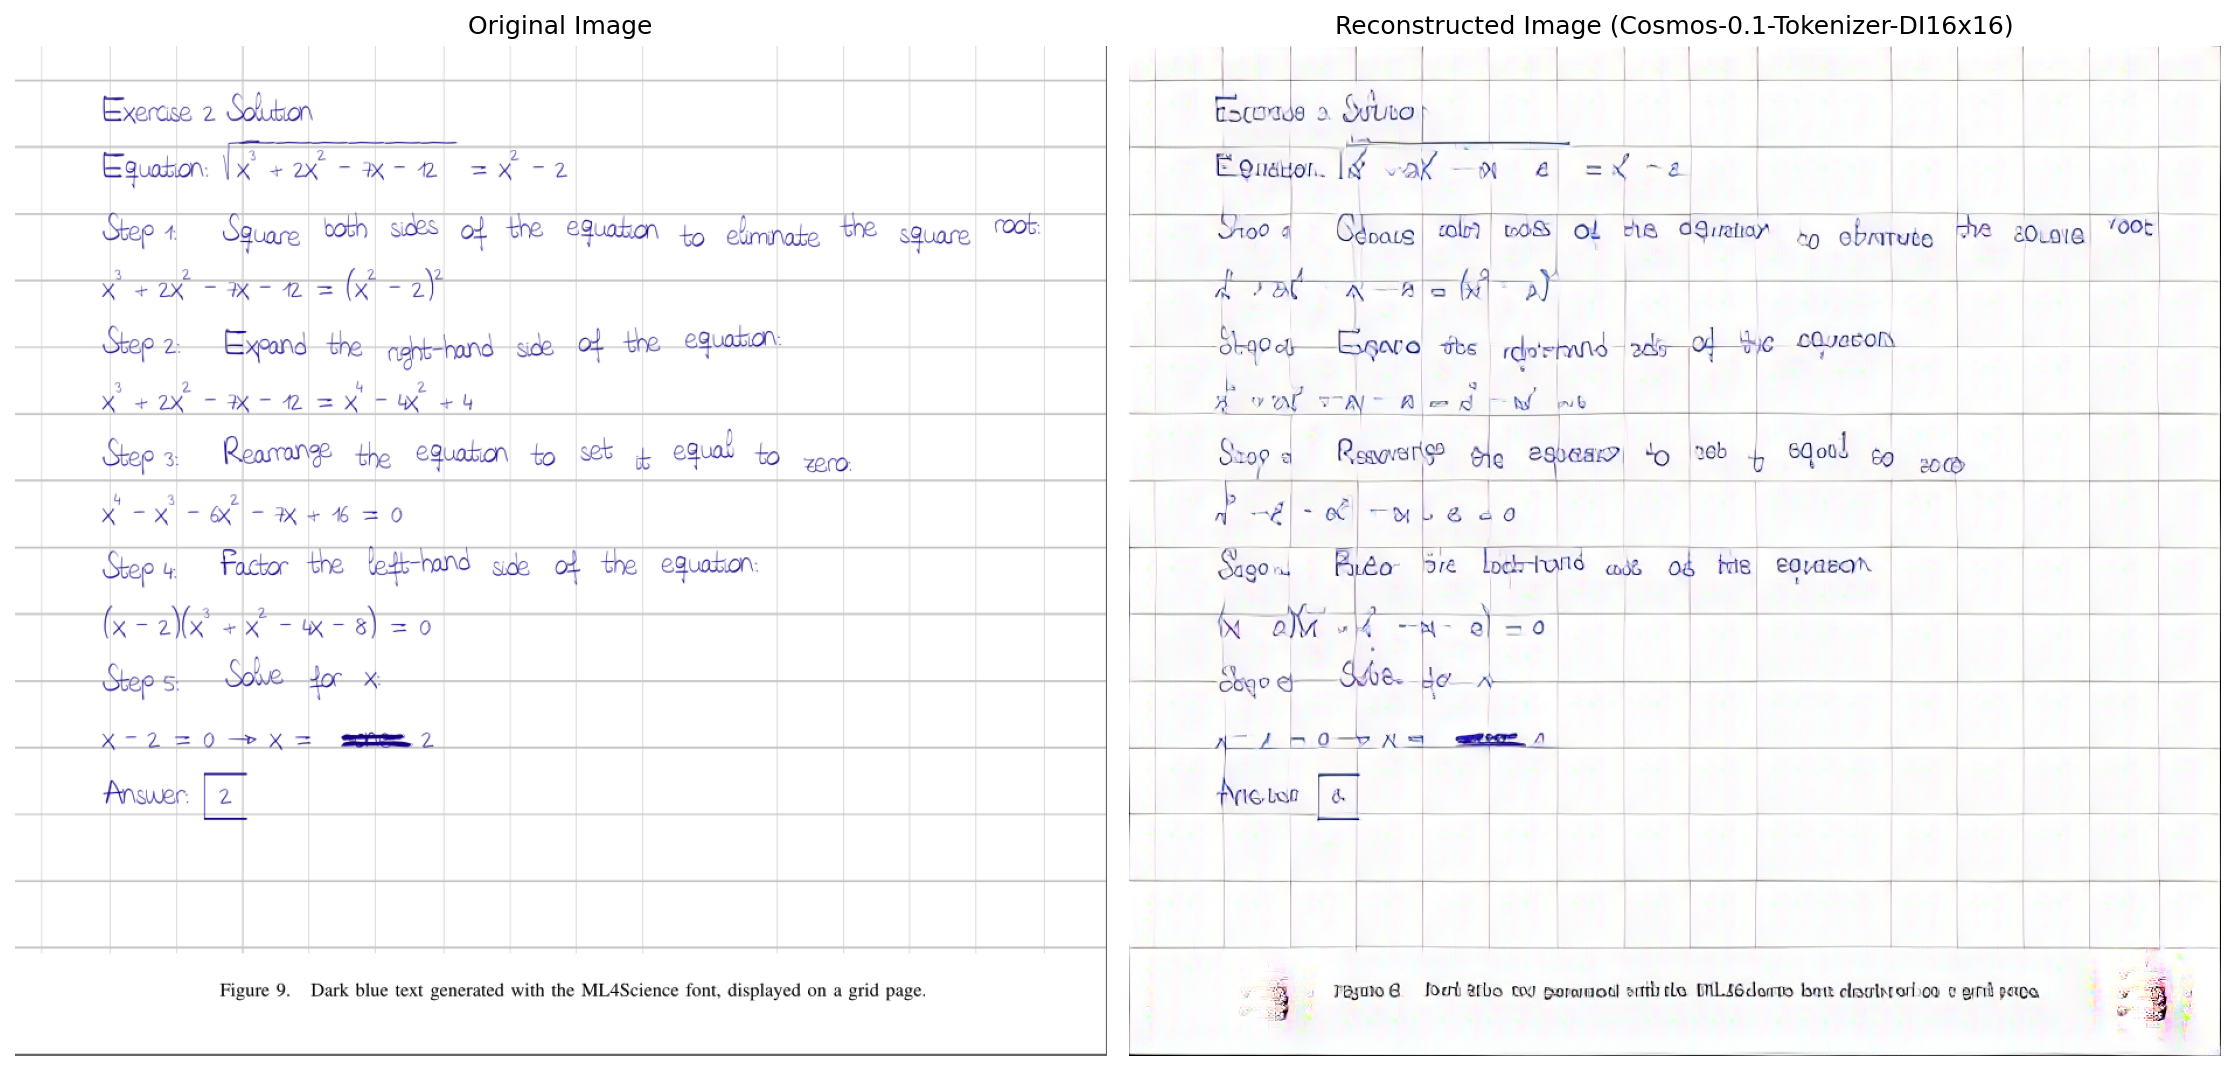

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from PIL import Image, ImageDraw, ImageFont

# Input image path
input_filepath = '/capstor/users/cscs/xyixuan/cosmos-predict1/cosmos_predict1/tokenizer/test_data/draft.jpg'

# Model configurations to test
model_configs = [
    "Cosmos-0.1-Tokenizer-CI8x8",
    "Cosmos-0.1-Tokenizer-CI16x16",
    "Cosmos-0.1-Tokenizer-DI8x8",
    "Cosmos-0.1-Tokenizer-DI16x16"
]

# Function to calculate tokens
def calculate_tokens(patch_size, image_shape):
    height, width = image_shape[0], image_shape[1]
    tokens_h = height // patch_size
    tokens_w = width // patch_size
    return tokens_h * tokens_w

# Function to calculate pixels
def calculate_pixels(image_shape):
    height, width = image_shape[0], image_shape[1]
    return height * width * 3  # RGB

# Function to add text that preserves image quality
def add_text_to_image(image_array, text_lines):
    # Convert to PIL with high quality
    image = Image.fromarray(image_array.astype(np.uint8))
    
    # Create new image with space for text
    new_height = image.height + 100
    new_image = Image.new('RGB', (image.width, new_height), (255, 255, 255))
    new_image.paste(image, (0, 0))
    
    # Add text
    draw = ImageDraw.Draw(new_image)
    try:
        font = ImageFont.truetype("arial.ttf", 16)
    except IOError:
        font = ImageFont.load_default()
    
    y_position = image.height + 10
    for line in text_lines:
        draw.text((10, y_position), line, fill=(0, 0, 0), font=font)
        y_position += 20
    
    return np.array(new_image)

# Read input image
input_image = media.read_image(input_filepath)[..., :3]
assert input_image.ndim == 3 and input_image.shape[2] == 3, "Image must have shape H x W x 3"

# Calculate original pixels
original_pixels = calculate_pixels(input_image.shape)

# Process images with high quality preservation
results = {}
for model_name in model_configs:
    print(f"Processing with {model_name}...")
    
    # Extract patch size
    patch_size = 8 if "8x8" in model_name else 16
    
    # Set checkpoint paths
    encoder_ckpt = f"checkpoints/{model_name}/encoder.jit"
    decoder_ckpt = f"checkpoints/{model_name}/decoder.jit"
    
    # Create tokenizer
    tokenizer = ImageTokenizer(
        checkpoint_enc=encoder_ckpt,
        checkpoint_dec=decoder_ckpt,
        device="cuda",
        dtype="bfloat16",
    )
    
    # Process image (same as media.show_images would use)
    batched_input_image = np.expand_dims(input_image, axis=0)
    batched_output_image = tokenizer(batched_input_image)
    output_image = batched_output_image[0]
    
    # Calculate metrics
    num_tokens = calculate_tokens(patch_size, input_image.shape)
    token_type = "Continuous" if "CI" in model_name else "Discrete"
    compression_ratio = original_pixels / num_tokens
    
    # Create text info
    text_lines = [
        f"Type: {token_type}",
        f"Patch size: {patch_size}x{patch_size}",
        f"Tokens: {num_tokens:,}",
        f"Original pixels: {original_pixels:,}",
        f"Compression ratio: {compression_ratio:.2f}:1"
    ]
    
    # Add text to image (with high quality)
    annotated_image = add_text_to_image(output_image, text_lines)
    
    # Save high-quality individual image
    input_dir, input_filename = os.path.split(input_filepath)
    filename, ext = os.path.splitext(input_filename)
    output_filepath = f"{input_dir}/{filename}_{model_name.split('-')[-1]}_hq{ext}"
    
    # Use media.write_image to preserve quality just like media.show_images
    media.write_image(output_filepath, annotated_image)
    
    # Store for PDF
    results[model_name] = {
        "output_image": annotated_image,
        "token_type": token_type,
        "patch_size": f"{patch_size}x{patch_size}",
        "num_tokens": num_tokens,
        "compression_ratio": compression_ratio
    }
    
    print(f"  Saved high-quality image to: {output_filepath}")

# Create high-resolution PDF
pdf_path = f"{input_dir}/{filename}_cosmos_comparison_hq.pdf"

with PdfPages(pdf_path) as pdf:
    # Create high-DPI figure
    plt.figure(figsize=(12, 18), dpi=300)  # Increased DPI for better quality
    
    # Original image (row 1)
    plt.subplot(3, 2, 1)
    plt.imshow(input_image)
    plt.title(f"Original Image\nPixels: {original_pixels:,}", fontsize=14)
    plt.axis('off')
    plt.subplot(3, 2, 2)
    plt.axis('off')
    
    # CI models (row 2)
    ci_models = [model for model in model_configs if "CI" in model]
    for i, model_name in enumerate(ci_models):
        plt.subplot(3, 2, 3 + i)
        plt.imshow(results[model_name]["output_image"])
        plt.title(f"{model_name}\n{results[model_name]['token_type']}, {results[model_name]['patch_size']}\n" +
                 f"Tokens: {results[model_name]['num_tokens']:,}\n" +
                 f"Compression: {results[model_name]['compression_ratio']:.2f}:1", 
                 fontsize=12)
        plt.axis('off')
    
    # DI models (row 3)
    di_models = [model for model in model_configs if "DI" in model]
    for i, model_name in enumerate(di_models):
        plt.subplot(3, 2, 5 + i)
        plt.imshow(results[model_name]["output_image"])
        plt.title(f"{model_name}\n{results[model_name]['token_type']}, {results[model_name]['patch_size']}\n" +
                 f"Tokens: {results[model_name]['num_tokens']:,}\n" +
                 f"Compression: {results[model_name]['compression_ratio']:.2f}:1", 
                 fontsize=12)
        plt.axis('off')
    
    plt.tight_layout()
    pdf.savefig(dpi=300)  # Save with high DPI
    plt.close()
    
    # Add summary table
    plt.figure(figsize=(10, 6), dpi=300)
    plt.axis('off')
    
    table_data = [
        ['Model', 'Type', 'Patch Size', 'Tokens', 'Compression Ratio'],
    ]
    
    for model in model_configs:
        table_data.append([
            model, 
            results[model]["token_type"], 
            results[model]["patch_size"], 
            f"{results[model]['num_tokens']:,}", 
            f"{results[model]['compression_ratio']:.2f}:1"
        ])
    
    table = plt.table(cellText=table_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 2)
    
    plt.title('Cosmos Image Tokenizer Comparison', fontsize=16, pad=20)
    pdf.savefig(dpi=300)  # Save with high DPI
    plt.close()

print(f"High-quality PDF comparison saved to: {pdf_path}")

# Alternative: Direct visualization using similar approach as media.show_images
# This is just to show the images with high quality during execution
plt.figure(figsize=(15, 10), dpi=150)
plt.subplot(1, 2, 1)
plt.imshow(input_image)
plt.title("Original Image")
plt.axis('off')

# Show the last processed output image
plt.subplot(1, 2, 2)
plt.imshow(output_image)  # Using the raw output before text addition
plt.title(f"Reconstructed Image ({model_configs[-1]})")
plt.axis('off')

plt.tight_layout()
plt.show()